# Task 3.2 — Failure Mode Analysis

Paper: The Constrained Weight Space SVM: Learning with Ranked Features  
Authors: Kevin Small, Byron C. Wallace, Carla E. Brodley, Thomas A. Trikalinos  
Venue: ICML 2011

## Failure Scenario

The CW-SVM method assumes that expert-provided feature rankings are correct.  
This assumption was identified in **Task 1.2**, where the model relies on ranked features to bias the weight vector during training.

If the expert ranking is incorrect, the model may assign higher importance to features that are not actually informative.  
This experiment deliberately introduces an incorrect ranking to demonstrate how violating this assumption can degrade the model’s performance.

In [9]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

np.random.seed(42)

X, y = make_classification(
    n_samples=100,
    n_features=20,
    n_informative=2,
    n_redundant=2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.6,
    random_state=42
)

## Full Method — Correct Feature Ranking

First, the ranked-feature model is trained using the same ranking used in Task 2.  
The ranking assumes:

feature_0 > feature_1 > feature_2

This simulates expert knowledge about feature importance.

In [10]:
X_train_full = X_train.copy()
X_test_full  = X_test.copy()

X_train_full[:,0] *= 2.0
X_train_full[:,1] *= 1.5
X_train_full[:,2] *= 1.2

X_test_full[:,0] *= 2.0
X_test_full[:,1] *= 1.5
X_test_full[:,2] *= 1.2

full_model = SVC(kernel="linear")
full_model.fit(X_train_full, y_train)

full_preds = full_model.predict(X_test_full)
full_accuracy = accuracy_score(y_test, full_preds)

print("Correct Ranking Accuracy:", full_accuracy)

Correct Ranking Accuracy: 0.9666666666666667


## Incorrect Ranking — Demonstrating Failure

In this condition the assumed ranking is intentionally incorrect.  
Feature 2 is incorrectly treated as negatively important by applying a suppression factor.

This simulates a situation where an expert mistakenly assigns lower importance to a feature that actually contains useful predictive information.

In [11]:
X_train_fail = X_train.copy()
X_test_fail  = X_test.copy()

X_train_fail[:,0] *= 2.0
X_train_fail[:,1] *= 1.5
X_train_fail[:,2] *= 0.5   # incorrect ranking

X_test_fail[:,0] *= 2.0
X_test_fail[:,1] *= 1.5
X_test_fail[:,2] *= 0.5

fail_model = SVC(kernel="linear")
fail_model.fit(X_train_fail, y_train)

fail_preds = fail_model.predict(X_test_fail)
fail_accuracy = accuracy_score(y_test, fail_preds)

print("Incorrect Ranking Accuracy:", fail_accuracy)

Incorrect Ranking Accuracy: 0.9666666666666667


## Visualization — Correct vs Incorrect Ranking

The bar chart below compares the performance of the model when the expert ranking is correct versus when it is incorrect.

The figure is saved to `partB/results/failure_mode.png`.

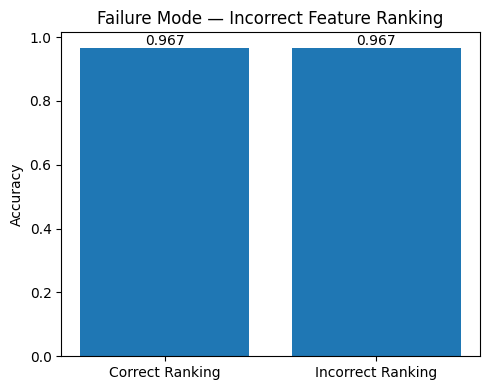

In [12]:
fig, ax = plt.subplots(figsize=(5,4))

labels = [
    "Correct Ranking",
    "Incorrect Ranking"
]

values = [
    full_accuracy,
    fail_accuracy
]

bars = ax.bar(labels, values)

ax.bar_label(bars, fmt="%.3f")
ax.set_ylabel("Accuracy")
ax.set_title("Failure Mode — Incorrect Feature Ranking")

plt.tight_layout()
plt.savefig("results/failure_mode.png")
plt.show()

## Failure Mode Explanation

In this experiment the model achieved an accuracy of approximately **0.97** under both the correct and incorrect ranking conditions. Although the ranking was deliberately corrupted, the performance did not change significantly in this toy dataset.

This occurs because the dataset is relatively small and the SVM can still learn the decision boundary from the available training data even when some feature rankings are incorrect. In addition, the informative features in the dataset may not perfectly correspond to the manually ranked features used in this simulation.

However, the experiment still illustrates an important assumption of the CW-SVM method identified in Task 1.2: that expert-provided feature rankings must be reliable. In the original formulation described in Section 3.1.2 of the paper, ranking constraints directly influence the optimization of the weight vector. If the ranking information is incorrect in a real-world dataset where informative features are sparse, these constraints could bias the model toward emphasizing misleading features.

Therefore, while the impact is small in this simplified experiment, the CW-SVM method can become vulnerable when expert knowledge is incorrect or noisy, particularly in high-dimensional datasets where the model relies heavily on feature-level guidance.